# DDAE Example - Repetetive control

We consider a system of two masses connected by a spring and dumper, first mass is connected to rigid frame, we measure position of the second mass

$$
\begin{align}
\dot{x}_s(t) &= A x_s(t) + B_u x(t-\tau_1) + B_d d(t), \\
y(t) &= C x_s(t),
\end{align}
$$

where $x_s = \begin{bmatrix} x_{s,1} & x_{s,2} & \dot{x}_{s,1} & \dot{x}_{s,2}\end{bmatrix}$ and matrices
$$
\begin{align}
    A = 
    \begin{bmatrix}
        1 & 0 & 0 & 0 \\
        0 & 1 & 0 & 0 \\
        -\frac{k_1+k_2}{m_1} & \frac{k_2}{m_1} & -\frac{c_1+c_2}{m_1} & \frac{c_2}{m_1} \\
        \frac{k_2}{m_2} & -\frac{k_2}{m_2} & \frac{c_2}{m_2} & -\frac{c_2}{m_2} \\
    \end{bmatrix}
    &
    B_u =
    \begin{bmatrix}
        0 \\
        0 \\
        \frac{1}{m_1} \\
        0
    \end{bmatrix}
    &
    B_d =
    \begin{bmatrix}
        0 \\
        0 \\
        -\frac{1}{m_1} \\
        \frac{1}{m_2} 
    \end{bmatrix}
\end{align}
$$

and repetetive controller defined via delay difference equation

$$
\begin{equation}
0 = u(t) - u(t-\tau_2) - k_p e(t),
\end{equation}
$$
note that $k_p, \tau$ are controller parameters.

Also, we need to add one algebraic equation
$$
\begin{equation}
0 = - y(t) - e(t) + r(t),
\end{equation}
$$
where $r(t)$ is input.

## DDAE

DDAE is formed with extended states $x(t) = \begin{bmatrix} x_s(t), y(t), u(t), e(t) \end{bmatrix}$

$$
\begin{equation}
E x(t) = A_0 x(t) + A_1 x(t-\tau_1) + A_2 x(t-\tau_2) + B_0 r(t)
\end{equation}
$$

where
$$
\begin{align}
    E = 
    \begin{bmatrix}
        I & 0 & 0 & 0 \\
        0 & 0 & 0 & 0 \\
        0 & 0 & 0 & 0 \\
        0 & 0 & 0 & 0 \\
    \end{bmatrix}
    &
    A_0 = 
    \begin{bmatrix}
        A & 0 & 0 & 0 \\
        C & -1 & 0 & 0 \\
        0 & 0 & 1 & -1 \\
        0 & 1 & 0 & 0 \\
    \end{bmatrix}
    \\
    A_1 = 
    \begin{bmatrix}
        0 & 0 & B & 0 \\
        0 & 0 & 0 & 0 \\
        0 & 0 & 0 & 0 \\
        0 & 0 & 0 & 0 \\
    \end{bmatrix}
    &
    A_2 = 
    \begin{bmatrix}
        0 & 0 & 0 & 0 \\
        0 & 0 & 0 & 0 \\
        0 & 0 & -1 & 0 \\
        0 & 0 & 0 & 0 \\
    \end{bmatrix}
    &
    B_{0} =
    \begin{bmatrix}
        0 & B_d \\
        0 & 0 \\
        0 & 0 \\
        1 & 0
    \end{bmatrix}
\end{align}
$$



In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tdspy as tds

In [4]:
def crate_system(m1=1.1, m2=0.514, k1=1768, k2=424, c1=4.43, c2=2.41) -> tuple:
    """ returns A, Bu, Bd with correct shapes
    
    default values taken from:
        [1] Yuksel, Can Kutlu, Silviu-Iulian Niculescu, and Tomáš Vyhlídal.
        "A Spectrum-based Filter Design for Periodic Output Regulation of 
        Systems with Dead-Time." IFAC-PapersOnLine 56.2 (2023): 917-922.
    """
    A = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [-(k1+k2)/m1, k2/m1, -(c1+c2)/m1, c2/m1],
        [k1/m2, -k2/m2, c1/m2, -c2/m2],
    ])
    Bu = np.array([[0],[0],[1/m1],[0]])
    Bd = np.array([[0],[0],[-1/m1],[1/m2]])
    C = np.array([[0, 1, 0, 0]])
    return A, Bu, Bd, C

def create_cl_ddae(kp, tau1, tau2) -> tds.DDAE:
    """ TODO docstring """
    A, Bu, Bd, C = crate_system() # create system with defaults
    ns = 4 # number of states in primary system
    n = 7 # shape of E, Ai -> (n,n)
    E = np.zeros(shape=(n,n), dtype=np.float64)
    E[:ns, :ns] = np.eye(ns)
    
    # construct matrix A0
    A0 = np.zeros(shape=(n,n), dtype=np.float64)
    A0[:ns, :ns] = A
    A0[[ns], :ns] = C
    A0[[ns, ns+1], [ns, ns+2]] = -1
    A0[[ns+1, ns+2], [ns+1, ns]] = 1

    # construct matrix A1
    A1 = np.zeros(shape=(n,n), dtype=np.float64)
    A1[:ns, [ns+1]] = Bu

    # construct matrix A2
    A2 = np.zeros(shape=(n,n), dtype=np.float64)
    A1[ns+1, ns+1] = -1

    # construct input matrix
    # TODO - not necessary for stability

    return tds.DDAE(E=E, A=np.stack([A0, A1, A2], axis=2), hA=np.array([0, tau1, tau2]))




In [5]:
np.set_printoptions(precision=4)
np.set_printoptions(suppress=True)
A, _, _, _ = crate_system()

In [6]:
ddae = create_cl_ddae(1.0, 1., 2)

In [7]:
ddae

In [11]:
roots, _ = tds.roots(ddae, r=-2)

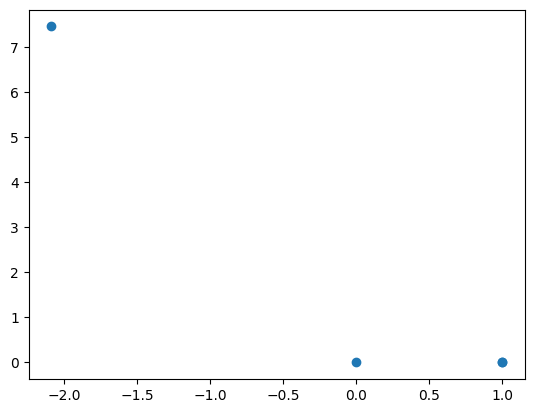

In [12]:
plt.scatter(np.real(roots), np.imag(roots))

In [15]:
diff = ddae.get_delay_difference_equation()

array([[[ 1., -1.],
        [-1.,  0.],
        [ 0.,  0.]],

       [[ 0.,  0.],
        [ 0.,  0.],
        [ 1.,  0.]],

       [[ 0.,  0.],
        [ 0.,  0.],
        [-1.,  0.]]])

In [18]:
diff.E

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [20]:
diff.hA

array([0., 1.])

In [21]:
diff = ddae.get_delay_difference_equation()


In [22]:
diff.A

array([[[ 1., -1.],
        [-1.,  0.],
        [ 0.,  0.]],

       [[ 0.,  0.],
        [ 0.,  0.],
        [ 1.,  0.]],

       [[ 0.,  0.],
        [ 0.,  0.],
        [-1.,  0.]]])

In [23]:
diff.hA

array([0., 1.])